# Calibration Cox

**This notebook assesses calibration performance of the Cox model and recalibrates predictions using isotonic regression for patients with advanced non-small cell lung cancer and high PDL1 receiving first-line pembrolizumab plus chemotherapy or pembrolizumab.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/cox_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180']]

In [4]:
survival_predictions_df.shape

(82739, 3)

In [5]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [6]:
pembro_pembrochemo_df.shape

(2064, 164)

In [7]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(2064, 166)

In [9]:
df = df.query('adv_diagnosis_year <= 2023')

In [10]:
df.shape

(1681, 166)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.0849, 0.592]",0.501764,0.473321,169,0.394359,0.546181
1,"(0.592, 0.665]",0.633554,0.526033,168,0.442189,0.595513
2,"(0.665, 0.714]",0.693568,0.627647,168,0.541836,0.691878
3,"(0.714, 0.748]",0.731884,0.638800,168,0.559611,0.706956
4,"(0.748, 0.773]",0.759958,0.796139,168,0.726647,0.849785
5,"(0.773, 0.797]",0.785134,0.775311,168,0.701836,0.832012
6,"(0.797, 0.819]",0.808680,0.813541,168,0.745538,0.865007
7,"(0.819, 0.839]",0.829565,0.863860,168,0.795316,0.904382
8,"(0.839, 0.867]",0.851777,0.878145,168,0.816310,0.918781
9,"(0.867, 0.942]",0.887075,0.957674,168,0.907018,0.976342


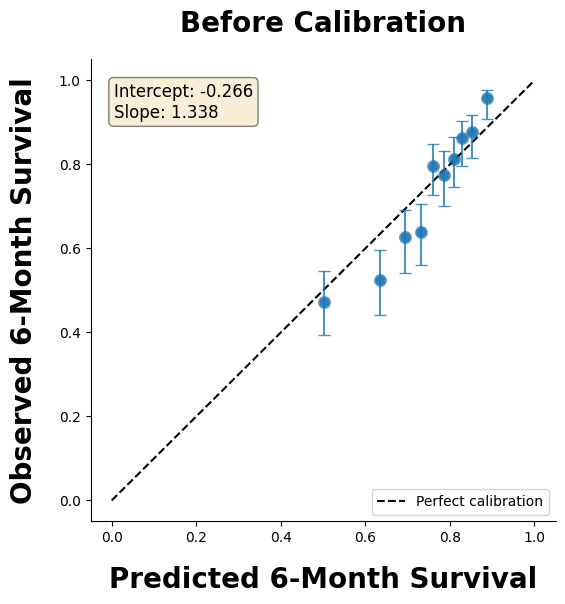

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1585

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1745

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1655

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1764

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1960

=== Summary ===
psurv_180_calibrated computed: 1681

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1742 ± 0.0127


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/cox_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.497]",0.453144,0.490312,174,0.410376,0.559823
1,"(0.497, 0.581]",0.535717,0.576092,180,0.494068,0.641073
2,"(0.581, 0.613]",0.597731,0.637633,156,0.549213,0.703984
3,"(0.613, 0.702]",0.676260,0.582978,167,0.502519,0.654985
4,"(0.702, 0.779]",0.772483,0.765417,212,0.701215,0.816689
5,"(0.779, 0.783]",0.782299,0.776192,148,0.697925,0.835631
6,"(0.783, 0.852]",0.845086,0.881040,174,0.819354,0.919942
7,"(0.852, 0.855]",0.852735,0.839141,139,0.758999,0.885772
8,"(0.855, 0.941]",0.895295,0.868223,163,0.805049,0.912034
9,"(0.941, 1.0]",0.970192,0.957569,168,0.906823,0.976288


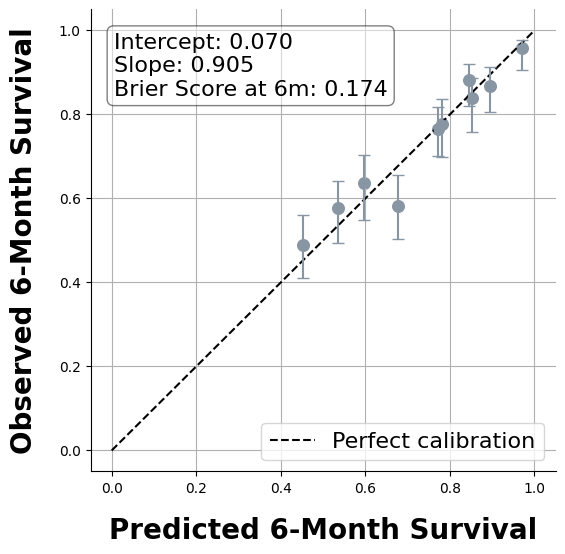

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()